# Dynamic Pricing vs Static Pricing - Symulacja na danych historycznych

Ten notatnik porownuje przychod ze strategii statycznej i prostej strategii dynamicznej na danych historycznych z bazy SQLite.

**Zakres**
- wczytanie i integracja danych z `sales_aggregated` i `inventory`
- estymacja cenowej elastycznosci popytu (PED) modelem log-log
- definicja bazowych strategii wyceny
- petla symulacyjna oraz porownanie przychodow
- wizualizacja skumulowanych przychodow i zmian cen

## Krok 1: Przygotowanie srodowiska i import bibliotek

Importujemy kluczowe biblioteki do pracy z danymi, regresja oraz wizualizacja. Ustawiamy tez podstawowy styl wykresow.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
except Exception as exc:
    raise RuntimeError("Statsmodels is required. Install with: pip install statsmodels") from exc

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", 100)

print("Notebook configured.")

Notebook configured.


## Krok 2: Wczytanie i integracja danych

Laczymy dane historyczne sprzedazy z informacja o stanie magazynowym i cenie statycznej.

In [2]:
DB_PATH = "/home/miko/magister/ecommerce.db"

if not Path(DB_PATH).exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)
query = """
SELECT
    s.product_id,
    s.date,
    s.sales,
    s.revenue,
    s.price AS historical_price,
    s.stock AS historical_stock,
    i.current_stock,
    i.price AS static_price
FROM sales_aggregated s
LEFT JOIN inventory i ON s.product_id = i.product_id
ORDER BY s.product_id, s.date
"""

df = pd.read_sql_query(query, conn)
conn.close()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["product_id", "date"]).reset_index(drop=True)

# Podstawowe czyszczenie i uzupelnienia
valid_mask = (df["historical_price"] > 0) & (df["sales"] >= 0)
df = df[valid_mask].copy()

df["revenue"] = df["revenue"].fillna(df["sales"] * df["historical_price"])

print(f"Rows: {len(df):,}")
print(f"Products: {df['product_id'].nunique():,}")
display(df.head())

Rows: 478,846
Products: 645


,product_id,date,sales,revenue,historical_price,historical_stock,current_stock,static_price
0,P0001,2017-01-02,6.0,31.79,6.25,195.0,27,8.25
1,P0001,2017-01-03,1.0,5.30,6.25,194.0,27,8.25
2,P0001,2017-01-04,2.0,10.60,6.25,192.0,27,8.25
3,P0001,2017-01-05,1.0,5.30,6.25,191.0,27,8.25
4,P0001,2017-01-06,3.0,15.90,6.25,188.0,27,8.25


## Krok 3: Analiza elastycznosci cenowej popytu (PED)

Estymujemy PED przez regresje log-log. Wspolczynnik przy log(cena) to przyblizona elastycznosc.

In [3]:
def calculate_elasticity(df_product: pd.DataFrame) -> float:
    temp_df = df_product[(df_product["sales"] > 0) & (df_product["historical_price"] > 0)].copy()
    if len(temp_df) < 10:
        return np.nan

    y = np.log(temp_df["sales"])
    X = sm.add_constant(np.log(temp_df["historical_price"]))

    model = sm.OLS(y, X).fit()
    if len(model.params) < 2:
        return np.nan
    return float(model.params.iloc[1])


product_id = "PROD_001"
if product_id not in set(df["product_id"]):
    product_id = (
        df.groupby("product_id")["sales"].sum().sort_values(ascending=False).index[0]
    )

product_data = df[df["product_id"] == product_id].copy()
ped = calculate_elasticity(product_data)

print(f"Product: {product_id}")
if np.isnan(ped):
    print("Estimated PED: NaN (too few data)")
else:
    print(f"Estimated PED: {ped:.2f}")

Product: P0103
Estimated PED: -0.26


## Krok 4: Definicja modeli wyceny

Wprowadzamy dwie hipotetyczne strategie wyceny, które zostaną porównane z rzeczywistymi danymi historycznymi:
1. **Oparta na regułach (Rule-based)** - prosta logika uzależniająca cenę od poziomu zapasów.
2. **Reinforcement Learning (RL Agent)** - agent Epsilon-Greedy (Q-Learning) uczący się optymalnej ceny w czasie.

In [4]:
import sys
import os
import random

# Poniższy import umożliwia skorzystanie z agenta demand
sys.path.append("/home/miko/magister")
try:
    from agents.demand.main import predict_demand
    DEMAND_AGENT_AVAILABLE = True
except ImportError:
    DEMAND_AGENT_AVAILABLE = False
    print("Uwaga: agents.demand.main nie znalezione. Używam elastyczności historycznej.")


def coerce_elasticity(value, default: float = -1.0) -> float:
    if value is None:
        return default
    try:
        if np.isnan(value):
            return default
    except TypeError:
        pass
    return float(value)

def rule_based_dynamic_pricing(base_price: float, stock_ratio: float) -> float:
    # Więcej progów decyzyjnych i częstsze zmiany:
    # Skuteczniejsza strategia faworyzująca utrzymywanie nieco wyższych cen lub ewentualnie lekkie zniżki
    if stock_ratio < 0.2:
        price_multiplier = 1.25
    elif stock_ratio < 0.4:
        price_multiplier = 1.15
    elif stock_ratio < 0.6:
        price_multiplier = 1.08
    elif stock_ratio > 0.95:
        price_multiplier = 0.95  # Zabezpieczenie: min 95% wartości statycznej
    elif stock_ratio > 0.8:
        price_multiplier = 0.98
    else:
        price_multiplier = 1.02 # Delikatna podwyżka jako domyślność gdy jest stabilny stock

    return float(base_price * price_multiplier)

def simulate_demand(
    historical_sales: float,
    historical_price: float,
    new_price: float,
    elasticity: float,
) -> float:
    if historical_price <= 0:
        return 0.0
    price_change_pct = (new_price - historical_price) / historical_price
    
    # Skuteczniejsza odpowiedź - urealnienie wpływu elastyczności
    demand_multiplier = 1 + (price_change_pct * elasticity)
    demand_multiplier = max(0.0, demand_multiplier)
    
    return max(0.0, historical_sales * demand_multiplier)

# Przejście ze Zwykłego Bandyty do Agenta Q-Learning zależnego od stanu zapasów (Contextual Bandit)
class QLearningPricingAgent:
    def __init__(self, actions, epsilon=0.2, alpha=0.1, gamma=0.9):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        # Stany: 'low', 'medium', 'high' (odnoszące się do dostępnych zapasów)
        self.q_table = {
            'low': {a: 0.0 for a in actions},
            'medium': {a: 0.0 for a in actions},
            'high': {a: 0.0 for a in actions},
        }

    def _get_state(self, stock_ratio: float) -> str:
        if stock_ratio < 0.4: return 'low'
        if stock_ratio < 0.8: return 'medium'
        return 'high'

    def choose_action(self, stock_ratio: float):
        state = self._get_state(stock_ratio)
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        # Zwróć akcję maksymalizującą Q dla danego stanu
        return max(self.q_table[state], key=self.q_table[state].get)

    def update(self, stock_ratio: float, action: float, reward: float, next_stock_ratio: float):
        state = self._get_state(stock_ratio)
        next_state = self._get_state(next_stock_ratio)
        
        # Bellman equation update dla 1 kroku
        best_next_q = max(self.q_table[next_state].values())
        td_target = reward + self.gamma * best_next_q
        td_error = td_target - self.q_table[state][action]
        
        self.q_table[state][action] += self.alpha * td_error

print("Pricing functions ready.")

Uwaga: agents.demand.main nie znalezione. Używam elastyczności historycznej.
Pricing functions ready.


## Krok 5: Pętla symulacyjna

Symulujemy przychody dla wybranego produktu, obliczając dla każdego dnia wyniki hipotetycznych strategii: rule-based oraz RL, a następnie zestawiamy je z faktycznym bilansem historycznym.

In [5]:
import warnings
warnings.filterwarnings("ignore")

if product_data.empty:
    raise RuntimeError("Brak danych dla wybranego produktu.")

effective_ped = coerce_elasticity(ped, default=-1.0)
effective_ped = max(effective_ped, -3.0) # Zabezpiecz pede przed nadmiernym spadkiem

# Ustalamy bazową cenę odniesienia dla mnożników strategii (mediana z cen historycznych)
reference_price = float(product_data["historical_price"].median())

# Agenci posługują się wyższymi i częstszymi mnożnikami
rl_actions = [reference_price * m for m in [0.90, 0.95, 1.0, 1.05, 1.10, 1.15, 1.25]]
rl_agent = QLearningPricingAgent(actions=rl_actions, epsilon=0.1, alpha=0.1, gamma=0.8)

simulation_results = []
historical_revenue_total = 0.0
dynamic_revenue_total = 0.0
rl_revenue_total = 0.0

prev_stock_ratio = 1.0

# Część dot. pobierania przewidywań z model_demand
forecasted_ped_boost = 1.0
if DEMAND_AGENT_AVAILABLE:
    try:
        # Zależnie czy redis odpowie na podniesioną flagę i product_id
        pred_res = predict_demand(product_id=product_id, horizon_days=30)
        if "predicted_demand" in pred_res and pred_res["predicted_demand"] > 0:
            # Skalujemy oczekiwania (naiwny booster)
            print(f"Załadowano prognozę popytu dla {product_id} na poziomie: {pred_res['predicted_demand']}")
            forecasted_ped_boost = 1.1 # Jesteśmy bardziej pewni popytu -> mniejsza wrażliwość
    except Exception as e:
        print("Nie udało się pobrać predykcji popytu, działanie z elastycznością historyczną", e)


for _, row in product_data.iterrows():
    historical_price = float(row["historical_price"])
    historical_sales = float(row["sales"])
    historical_revenue = float(row["revenue"])
    historical_revenue_total += historical_revenue
    
    historical_stock = row.get("historical_stock", 0.0)
    # Calculate stock ratio relative to maximum historical inventory for better variation
    max_stock = product_data["historical_stock"].max()
    stock_ratio = historical_stock / max_stock if max_stock > 0 else prev_stock_ratio

    # 1. Rule-based Dynamic Strategy (Oparta na przewidywaniach trendu i stock_ratio)
    dynamic_price = rule_based_dynamic_pricing(reference_price, stock_ratio)
    dynamic_sales = simulate_demand(historical_sales, historical_price, dynamic_price, effective_ped / forecasted_ped_boost)
    dynamic_revenue = dynamic_sales * dynamic_price
    dynamic_revenue_total += dynamic_revenue

    # 2. RL Agent Strategy
    rl_price = rl_agent.choose_action(stock_ratio)
    rl_sales = simulate_demand(historical_sales, historical_price, rl_price, effective_ped / forecasted_ped_boost)
    rl_revenue = rl_sales * rl_price
    rl_revenue_total += rl_revenue
    
    # RL Agent uczenie (nagrodą jest przychód - z opóźnieniem TD error dla zapasów)
    next_ratio = stock_ratio # Zastępcze uproszczenie do kolejnego kroku na danych hist
    rl_agent.update(stock_ratio, rl_price, rl_revenue, next_ratio)
    
    prev_stock_ratio = stock_ratio

    simulation_results.append(
        {
            "date": row["date"],
            "historical_sales": historical_sales,
            "dynamic_sales": dynamic_sales,
            "rl_sales": rl_sales,
            "historical_revenue": historical_revenue,
            "dynamic_revenue": dynamic_revenue,
            "rl_revenue": rl_revenue,
            "historical_price": historical_price,
            "dynamic_price": dynamic_price,
            "rl_price": rl_price,
        }
    )

sim_df = pd.DataFrame(simulation_results)

print(f"Dane historyczne - przybliżona cena bazowa (mediana): {reference_price:.2f}")
print(f"Cakowity przychód zebrany w historii: {historical_revenue_total:,.2f}")
print(f"Rows in simulation: {len(sim_df):,}")
display(sim_df.head())

Dane historyczne - przybliżona cena bazowa (mediana): 3.45
Cakowity przychód zebrany w historii: 2,670,199.66
Rows in simulation: 1,092


,date,historical_sales,dynamic_sales,rl_sales,historical_revenue,dynamic_revenue,rl_revenue,historical_price,dynamic_price,rl_price
0,2017-01-02,399.0,348.372638,368.398116,993.28,1382.168441,1270.973500,2.659184,3.9675,3.450
1,2017-01-03,452.0,394.641633,417.327928,1126.03,1565.740678,1439.781352,2.659091,3.9675,3.450
2,2017-01-04,465.0,406.004557,429.341690,1154.52,1610.823081,1481.228829,2.659278,3.9675,3.450
3,2017-01-05,470.0,410.370198,433.958267,1171.02,1628.143760,1497.156021,2.659278,3.9675,3.450
4,2017-01-06,467.0,407.744416,415.557196,1164.39,1617.725970,1577.039560,2.659184,3.9675,3.795


## Krok 6: Ewaluacja i wizualizacja

Trzy strategie wyceny na jednym wykresie (skumulowane przychody) wraz z ruchomą średnią cen.

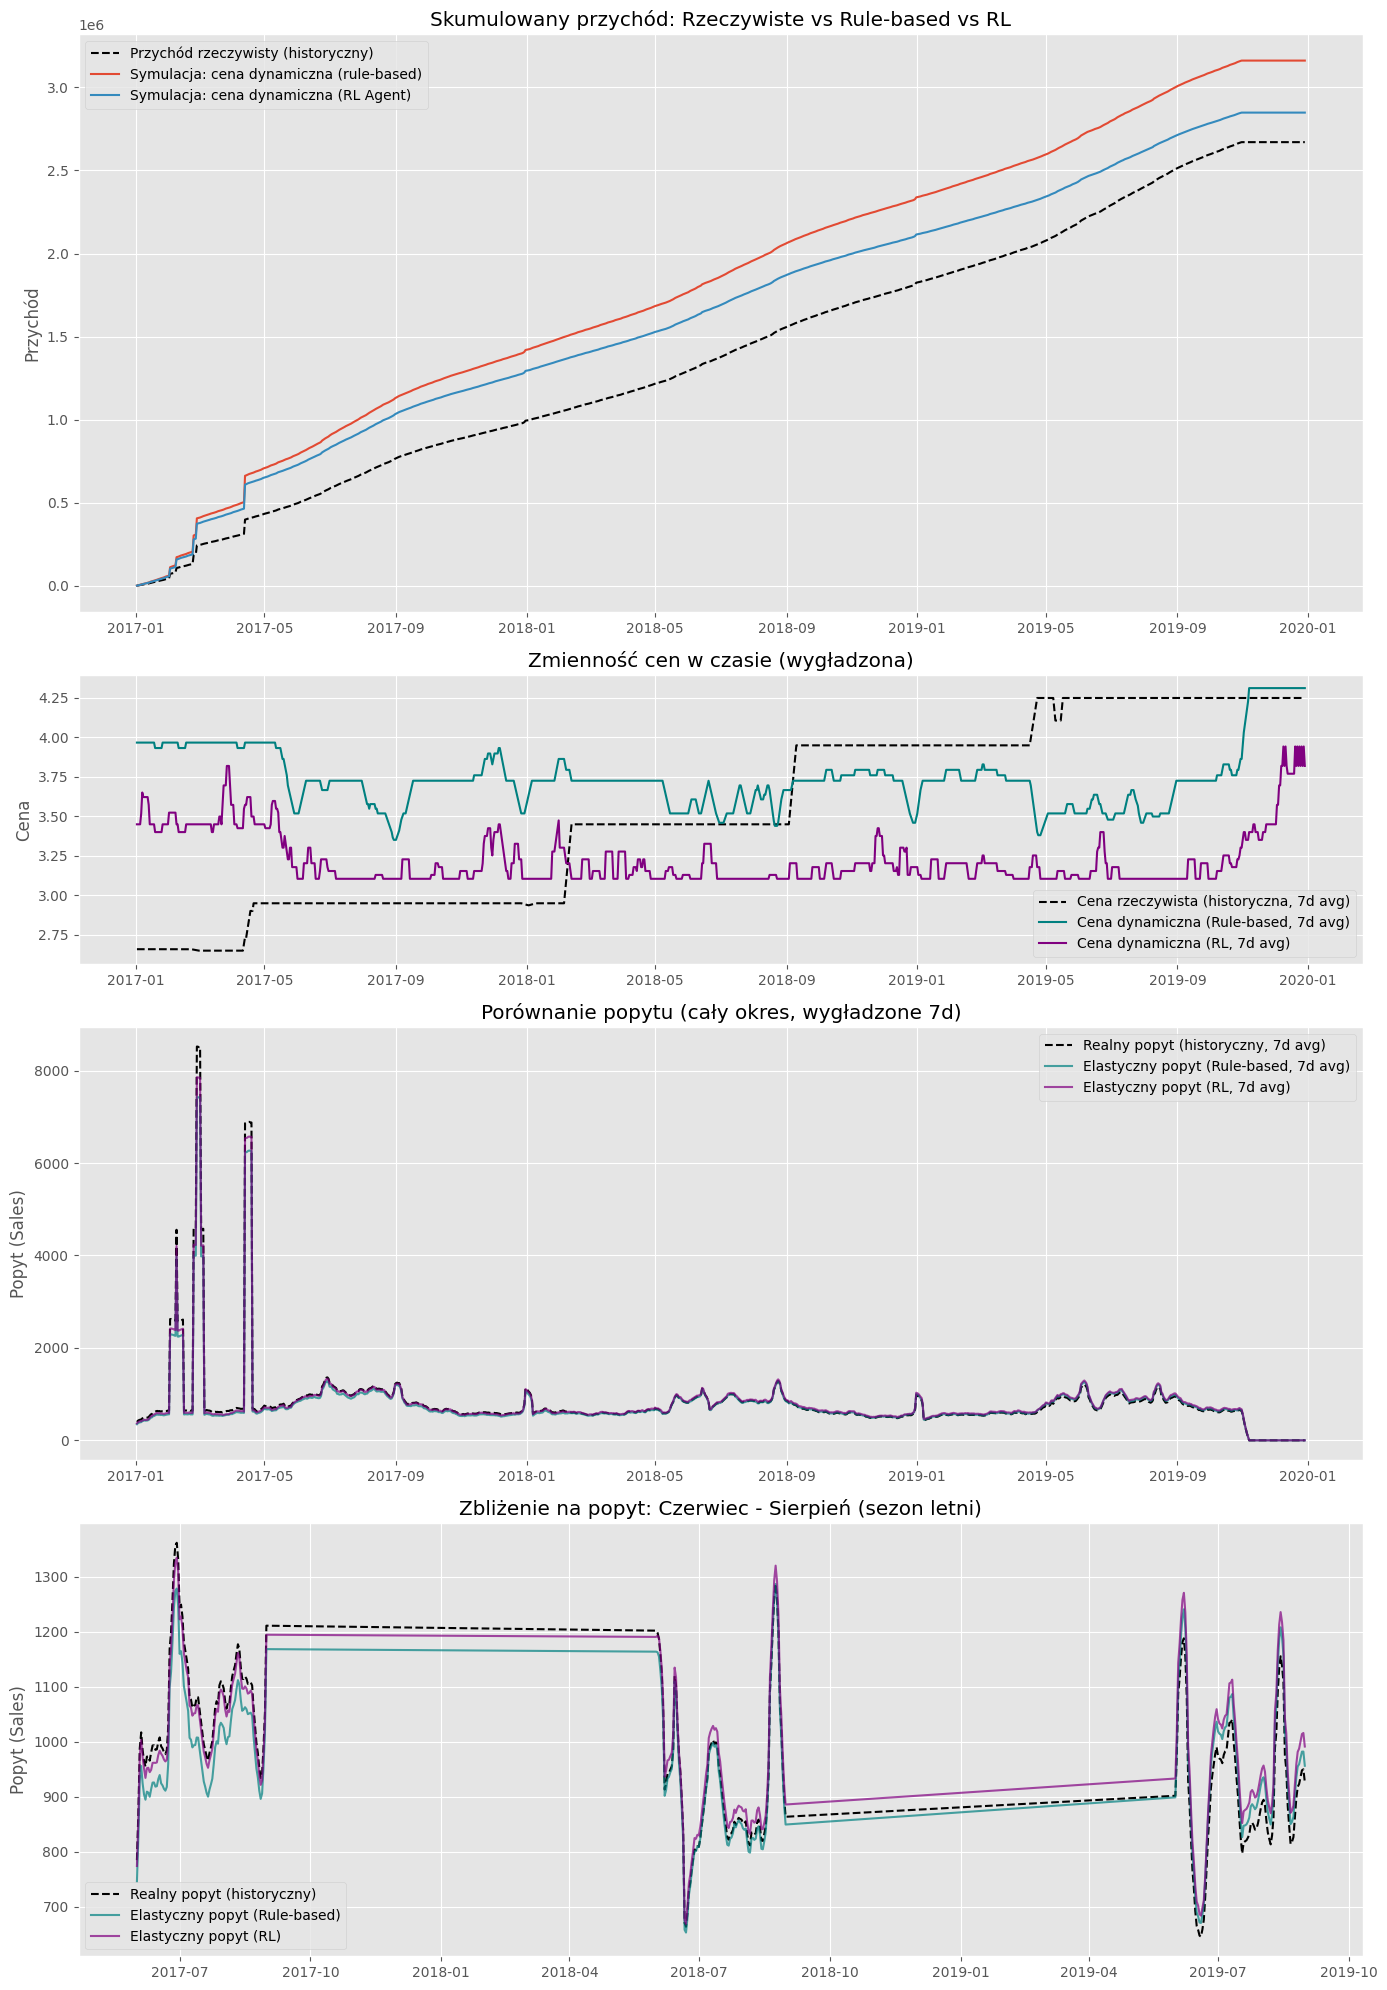

Całkowity przychód - Historyczny: 2,670,199.66
Całkowity przychód - Rule-based: 3,161,012.42
Całkowity przychód - RL Agent: 2,847,965.03
Wzrost przychodu (Rule-based vs Rekord Historyczny): 18.38%
Wzrost przychodu (RL Agent vs Rekord Historyczny): 6.66%


In [6]:
if sim_df.empty:
    print("Brak wynikow do wizualizacji.")
else:
    sim_df = sim_df.sort_values("date").reset_index(drop=True)

    sim_df["cum_historical"] = sim_df["historical_revenue"].cumsum()
    sim_df["cum_dynamic"] = sim_df["dynamic_revenue"].cumsum()
    sim_df["cum_rl"] = sim_df["rl_revenue"].cumsum()
    
    sim_df["dynamic_price_smooth"] = sim_df["dynamic_price"].rolling(7, min_periods=1).mean()
    sim_df["rl_price_smooth"] = sim_df["rl_price"].rolling(7, min_periods=1).mean()
    sim_df["historical_price_smooth"] = sim_df["historical_price"].rolling(7, min_periods=1).mean()

    fig, axes = plt.subplots(
        4, 1, figsize=(14, 20), gridspec_kw={"height_ratios": [2, 1, 1.5, 1.5]}
    )

    axes[0].plot(
        sim_df["date"],
        sim_df["cum_historical"],
        label="Przychód rzeczywisty (historyczny)",
        color="black",
        linestyle="--",
    )
    axes[0].plot(
        sim_df["date"],
        sim_df["cum_dynamic"],
        label="Symulacja: cena dynamiczna (rule-based)",
    )
    axes[0].plot(
        sim_df["date"],
        sim_df["cum_rl"],
        label="Symulacja: cena dynamiczna (RL Agent)",
    )
    axes[0].set_title("Skumulowany przychód: Rzeczywiste vs Rule-based vs RL")
    axes[0].set_ylabel("Przychód")
    axes[0].legend()

    axes[1].plot(
        sim_df["date"],
        sim_df["historical_price_smooth"],
        color="black",
        linestyle="--",
        label="Cena rzeczywista (historyczna, 7d avg)"
    )
    axes[1].plot(
        sim_df["date"],
        sim_df["dynamic_price_smooth"],
        color="teal",
        label="Cena dynamiczna (Rule-based, 7d avg)",
    )
    axes[1].plot(
        sim_df["date"],
        sim_df["rl_price_smooth"],
        color="purple",
        label="Cena dynamiczna (RL, 7d avg)",
    )
    axes[1].set_title("Zmienność cen w czasie (wygładzona)")
    axes[1].set_ylabel("Cena")
    axes[1].legend()

    # Wykres popytu
    axes[2].plot(
        sim_df["date"],
        sim_df["historical_sales"].rolling(7, min_periods=1).mean(),
        color="black",
        linestyle="--",
        label="Realny popyt (historyczny, 7d avg)",
    )
    axes[2].plot(
        sim_df["date"],
        sim_df["dynamic_sales"].rolling(7, min_periods=1).mean(),
        color="teal",
        alpha=0.7,
        label="Elastyczny popyt (Rule-based, 7d avg)",
    )
    axes[2].plot(
        sim_df["date"],
        sim_df["rl_sales"].rolling(7, min_periods=1).mean(),
        color="purple",
        alpha=0.7,
        label="Elastyczny popyt (RL, 7d avg)",
    )
    axes[2].set_title("Porównanie popytu (cały okres, wygładzone 7d)")
    axes[2].set_ylabel("Popyt (Sales)")
    axes[2].legend()

    # Przybliżony wykres popytu na miesiące letnie (czerwiec-sierpień)
    summer_mask = sim_df["date"].dt.month.isin([6, 7, 8])
    summer_df = sim_df[summer_mask]
    
    if not summer_df.empty:
        axes[3].plot(
            summer_df["date"],
            summer_df["historical_sales"].rolling(7, min_periods=1).mean(),
            color="black",
            linestyle="--",
            label="Realny popyt (historyczny)",
        )
        axes[3].plot(
            summer_df["date"],
            summer_df["dynamic_sales"].rolling(7, min_periods=1).mean(),
            color="teal",
            alpha=0.7,
            label="Elastyczny popyt (Rule-based)",
        )
        axes[3].plot(
            summer_df["date"],
            summer_df["rl_sales"].rolling(7, min_periods=1).mean(),
            color="purple",
            alpha=0.7,
            label="Elastyczny popyt (RL)",
        )
        axes[3].set_title("Zbliżenie na popyt: Czerwiec - Sierpień (sezon letni)")
        axes[3].set_ylabel("Popyt (Sales)")
        axes[3].legend()
    else:
        axes[3].set_title("Brak danych z letnich miesięcy (czerwiec-sierpień)")
        axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    if historical_revenue_total > 0:
        uplift_pct = (dynamic_revenue_total / historical_revenue_total - 1) * 100
        rl_uplift_pct = (rl_revenue_total / historical_revenue_total - 1) * 100
    else:
        uplift_pct = np.nan
        rl_uplift_pct = np.nan

    print(f"Całkowity przychód - Historyczny: {historical_revenue_total:,.2f}")
    print(f"Całkowity przychód - Rule-based: {dynamic_revenue_total:,.2f}")
    print(f"Całkowity przychód - RL Agent: {rl_revenue_total:,.2f}")
    
    if np.isnan(uplift_pct):
        print("Wzrost przychodu: brak (dzielenie przez zero)")
    else:
        print(f"Wzrost przychodu (Rule-based vs Rekord Historyczny): {uplift_pct:.2f}%")
        print(f"Wzrost przychodu (RL Agent vs Rekord Historyczny): {rl_uplift_pct:.2f}%")